In [ ]:
from netCDF4 import Dataset
import netCDF4 as netcdf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import pandas as pd
import scipy.ndimage as ndimage
import datetime
import glob
import os
import sys
import csv
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
def ncdump(nc_fid, verb=True):
    def print_ncattr(key):
        try:
            print ("\t\ttype:", repr(nc_fid.variables[key].dtype))
            for ncattr in nc_fid.variables[key].ncattrs():
                print ('\t\t%s:' % ncattr,repr(nc_fid.variables[key].getncattr(ncattr)))
        except KeyError:
            print ("\t\tWARNING: %s does not contain variable attributes" % key)

    # NetCDF global attributes
    nc_attrs = nc_fid.ncattrs()
    if verb:
        print ("NetCDF Global Attributes:")
        for nc_attr in nc_attrs:
            print ('\t%s:' % nc_attr, repr(nc_fid.getncattr(nc_attr)))
    nc_dims = [dim for dim in nc_fid.dimensions]
    if verb:
        print ("NetCDF dimension information:")
        for dim in nc_dims:
            print ("\tName:", dim)
            print ("\t\tsize:", len(nc_fid.dimensions[dim]))
            print_ncattr(dim)
    nc_vars = [var for var in nc_fid.variables]
    if verb:
        print ("NetCDF variable information:")
        for var in nc_vars:
            if var not in nc_dims:
                print ('\tName:', var)
                print ("\t\tdimensions:", nc_fid.variables[var].dimensions)
                print ("\t\tsize:", nc_fid.variables[var].size)
                print_ncattr(var)
    return nc_attrs, nc_dims, nc_vars

def trunc(values, decs=0):
    return np.trunc(values*10**decs)/(10**decs)

def timeIndexToDatetime(baseTime,times):
    newTimes=[]
    for ts in times:
        newTimes.append(baseTime+datetime.timedelta(seconds=ts))

    return newTimes

In [ ]:
num = 0
for netcdf_file in glob.glob('C:/Users/user/Desktop/Python/cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m_1772597659853.nc'):
    directory, ncfilename = os.path.split(netcdf_file)
    indexposition = directory+'/'+ncfilename
    ncfile = netcdf.Dataset(directory+'/'+ncfilename)
    if num < 1:
        nc_attrs, nc_dims, nc_vars = ncdump(ncfile)
        num = num+1
        print(ncfile)
    else:
        num = num+1
dataset = xr.open_dataset('C:/Users/user/Desktop/Python/cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m_1772597659853.nc')
print(dataset)

NetCDF Global Attributes:
	Conventions: 'CF-1.11'
	title: 'daily mean fields from Global Ocean Physics Analysis and Forecast updated Daily'
	institution: 'Mercator Ocean International'
	producer: 'CMEMS - Global Monitoring and Forecasting Centre'
	source: 'MOI GLO12'
	credit: 'E.U. Copernicus Marine Service Information (CMEMS)'
	contact: 'https://marine.copernicus.eu/contact'
	references: 'http://marine.copernicus.eu'
	subset:source: 'ARCO data downloaded from the Marine Data Store using the MyOcean Data Portal'
	subset:productId: 'GLOBAL_ANALYSISFORECAST_PHY_001_024'
	subset:datasetId: 'cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m_202406'
	subset:date: '2026-03-04T04:14:19.853Z'
NetCDF dimension information:
	Name: time
		size: 366
		type: dtype('float64')
		standard_name: 'time'
		long_name: 'Time'
		units: 'seconds since 1970-01-01 00:00:00'
		calendar: 'gregorian'
		axis: 'T'
	Name: depth
		size: 1
		type: dtype('float32')
		standard_name: 'depth'
		long_name: 'Depth'
		units: 'm'


In [ ]:
#=================== Identifikasi Variabel ==================
lat=ncfile.variables['latitude'][:]
lon=ncfile.variables['longitude'][:]
time=ncfile.variables['time'][:]
depth=np.array(ncfile.variables['depth'][:])
sst=np.array(ncfile.variables['thetao'][:,:,:,:])
lat1 = dataset.latitude.values
lon1 = dataset.longitude.values
depth1 = dataset.depth.values
time1 = dataset.time.values
sst1 = dataset.thetao

#=================== Identifikasi Atribut ==================
_FillValueu = ncfile.variables['thetao']._FillValue
#add_offset = ncfile.variables['thetao'].add_offset
#scale_factor = ncfile.variables['thetao'].scale_factor
units = ncfile.variables['thetao'].units

In [ ]:
myLat=-2
myLon=118
lonIdx=(np.abs(lon-myLon)).argmin()
latIdx=(np.abs(lat-myLat)).argmin()
print("Input Lokasi Titik:",myLon,myLat)
print("Titik Terdekat dari Data Input:", lon[lonIdx],lat[latIdx])

Input Lokasi Titik: 118 -2
Titik Terdekat dari Data Input: 118.000015 -2.0


In [6]:
#print(suhu_titik1)
#print(sst1.values)
print(sst1)

<xarray.DataArray 'thetao' (time: 366, depth: 1, latitude: 104, longitude: 50)> Size: 8MB
[1903200 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2026-01-01
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 416B -6.25 -6.167 -6.083 ... 2.167 2.25 2.333
  * longitude  (longitude) float32 200B 116.3 116.3 116.4 ... 120.2 120.3 120.3
Attributes:
    units:          degrees_C
    standard_name:  sea_water_potential_temperature
    long_name:      Temperature
    cell_methods:   area: mean
    unit_long:      Degrees Celsius
    valid_max:      40.0
    valid_min:      -10.0


In [ ]:
from pandas import Series, date_range, DataFrame
tanggal = date_range(start='01/01/2025 12:00:00', end='01/01/2026 12:00:00',freq='1D') #bulan, hari, tahun, jam, menit, detik
print(tanggal)

DatetimeIndex(['2025-01-01 12:00:00', '2025-01-02 12:00:00',
               '2025-01-03 12:00:00', '2025-01-04 12:00:00',
               '2025-01-05 12:00:00', '2025-01-06 12:00:00',
               '2025-01-07 12:00:00', '2025-01-08 12:00:00',
               '2025-01-09 12:00:00', '2025-01-10 12:00:00',
               ...
               '2025-12-23 12:00:00', '2025-12-24 12:00:00',
               '2025-12-25 12:00:00', '2025-12-26 12:00:00',
               '2025-12-27 12:00:00', '2025-12-28 12:00:00',
               '2025-12-29 12:00:00', '2025-12-30 12:00:00',
               '2025-12-31 12:00:00', '2026-01-01 12:00:00'],
              dtype='datetime64[us]', length=366, freq='D')


In [7]:
#print(dataset.time)
# Ubah atribut short_name menjadi label sumbu Y
sst1.attrs['standard_name'] = sst1.attrs['long_name']


In [16]:
lon_titik=118
lat_titik=-2
data_titik = sst1.sel(longitude=lon_titik, latitude=lat_titik, method='nearest').isel(depth=0)

rata_rata_bulanan = data_titik.resample(time='1MS').mean()

for d in rata_rata_bulanan:
    waktu = d.time.dt.strftime('%B %Y').values
    nilai = d.values
    print(f'{waktu}, Nilai: {nilai}' )

January 2025, Nilai: 29.845035552978516
February 2025, Nilai: 29.992616653442383
March 2025, Nilai: 29.819852828979492
April 2025, Nilai: 30.303802490234375
May 2025, Nilai: 30.523799896240234
June 2025, Nilai: 30.13639259338379
July 2025, Nilai: 29.595046997070312
August 2025, Nilai: 29.69222640991211
September 2025, Nilai: 29.900285720825195
October 2025, Nilai: 30.08006477355957
November 2025, Nilai: 30.178197860717773
December 2025, Nilai: 30.174997329711914
January 2026, Nilai: 30.12751579284668


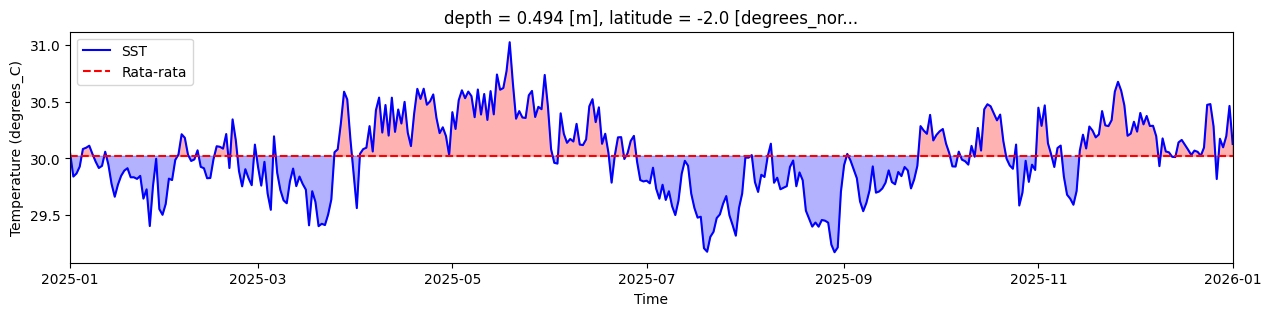

In [ ]:
import matplotlib.dates as mdates
data_plot=sst1.sel(longitude=118, latitude=-2, method='nearest').isel(depth=0)
rerata_plot=data_plot.mean().values

fig, ax1 = plt.subplots(1, 1, sharex=True,figsize=(15,3),facecolor="white")
data_plot.plot(ax=ax1, color='blue', label='SST')
ax1.axhline(y=rerata_plot, color='red', linestyle='--', label='Rata-rata')
ax1.fill_between(data_plot.time, data_plot.values, rerata_plot, 
                 where=(data_plot.values > rerata_plot), color='red', 
                 alpha=0.3, interpolate=True)
ax1.fill_between(data_plot.time, data_plot.values, rerata_plot, 
                 where=(data_plot.values < rerata_plot), color='blue', 
                 alpha=0.3, interpolate=True)

ax1.set_ylabel(sst1.attrs['long_name'] + ' (' + sst1.attrs['units'] + ')')
ax1.margins(x=0)  # Hilangkan margin pada sumbu X

#ax1.set_xlim([pd.to_datetime('2025-01-01'), pd.to_datetime('2026-01-01')])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend()
plt.show()

<class 'matplotlib.axes._axes.Axes'>


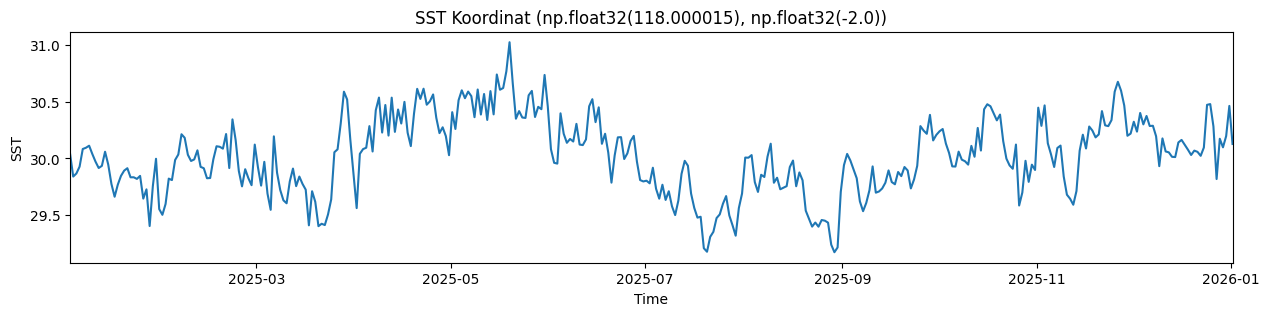

In [ ]:
fig, ax1 = plt.subplots(1, 1, sharex=True,figsize=(15,3),facecolor="white")
#=================== Plotting sst ==================
ax1.plot(tanggal,sst[:,0,latIdx,lonIdx])
ax1.set_title(f"SST Koordinat {lon[lonIdx],lat[latIdx]}")
ax1.set_ylabel('SST')
ax1.set_xlabel('Time')
ax1.set_xlim([tanggal[0],tanggal[len(tanggal)-1]])
print(type(ax1))

# Ekstrak Data

In [20]:
#('time', 'depth', 'latitude', 'longitude')
import os
for i in range(0, len(time),1):
    sst_val = sst[i,0,:,:]
    date = str(tanggal[i])
    year = date[0:4]
    month = date[5:7]
    day = date[8:10]
    location = 'C:/Users/user/Desktop/Python/Ekstrak SST/'+year+'/'+month+'/'
    try:
        os.makedirs(location)
    except:
        print(year,month,day)
    sst_save = np.savez(location+'vst_'+year+month+day+'.npz', a=sst_val, b=lon, c=lat)

2025 01 02
2025 01 03
2025 01 04
2025 01 05
2025 01 06
2025 01 07
2025 01 08
2025 01 09
2025 01 10
2025 01 11
2025 01 12
2025 01 13
2025 01 14
2025 01 15
2025 01 16
2025 01 17
2025 01 18
2025 01 19
2025 01 20
2025 01 21
2025 01 22
2025 01 23
2025 01 24
2025 01 25
2025 01 26
2025 01 27
2025 01 28
2025 01 29
2025 01 30
2025 01 31
2025 02 02
2025 02 03
2025 02 04
2025 02 05
2025 02 06
2025 02 07
2025 02 08
2025 02 09
2025 02 10
2025 02 11
2025 02 12
2025 02 13
2025 02 14
2025 02 15
2025 02 16
2025 02 17
2025 02 18
2025 02 19
2025 02 20
2025 02 21
2025 02 22
2025 02 23
2025 02 24
2025 02 25
2025 02 26
2025 02 27
2025 02 28
2025 03 02
2025 03 03
2025 03 04
2025 03 05
2025 03 06
2025 03 07
2025 03 08
2025 03 09
2025 03 10
2025 03 11
2025 03 12
2025 03 13
2025 03 14
2025 03 15
2025 03 16
2025 03 17
2025 03 18
2025 03 19
2025 03 20
2025 03 21
2025 03 22
2025 03 23
2025 03 24
2025 03 25
2025 03 26
2025 03 27
2025 03 28
2025 03 29
2025 03 30
2025 03 31
2025 04 02
2025 04 03
2025 04 04
2025 04 05

In [ ]:
sst_monthly = sst1.resample(time='1MS').mean()
sst_yearly = sst1.resample(time='1YS').mean()
sst_climatology = sst1.groupby('time.month').mean()
sst_climatology1= dataset['thetao'].groupby('time.month').mean().load()

print(sst_climatology)
print(sst_climatology1)

In [22]:
lon_titik = 118
lat_titik = -2
vmin_global = float(sst1.min())
vmax_global = float(sst1.max())

print(vmin_global)
print(vmax_global)


25.968265533447266
32.20175552368164


In [23]:
for i in range(len(sst_monthly.time)):
    data_bulan_ini = sst_monthly.isel(time=i).isel(depth=0)
    tahun_bulan = data_bulan_ini.time.dt.strftime('%Y-%m').values
    data_clean = data_bulan_ini.where(data_bulan_ini > 0)
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    p = data_clean.plot.contourf(
        ax=ax, 
        transform=ccrs.PlateCarree(),
        levels=100, 
        cmap='turbo', 
        add_colorbar=False,
        #vmin=vmin_global,
        #vmax=vmax_global,
        robust=True,
        extend='both'
    )
    
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.COASTLINE)
    ax.set_extent([lon1.min(), lon1.max(), lat1.min(), lat1.max()])
    ax.plot(lon_titik, lat_titik, marker='o', color='black', markersize=8, 
            markeredgecolor='white', transform=ccrs.PlateCarree(), label='lokasi pengamatan')
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    plt.colorbar(p, orientation='horizontal', pad=0.08, label=f'SST ({units})')
    plt.title(f'SST Bulanan - {tahun_bulan}', fontsize=15)

    plt.savefig(f'C:/Users/user/Desktop/Python/Hasil Monthly/{tahun_bulan}.png', dpi=300)
    plt.close()


In [18]:
for i in range(len(sst_yearly.time)):
    data_tahunan = sst_yearly.isel(time=i).isel(depth=0)
    tahun = data_tahunan.time.dt.strftime('%Y').values
    
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    p = data_tahunan.plot.contourf(
        ax=ax, 
        transform=ccrs.PlateCarree(),
        levels=100, 
        cmap='turbo', 
        add_colorbar=False,
        robust=True,
        extend='both'
    )
    
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.COASTLINE)
    ax.set_extent([lon1.min(), lon1.max(), lat1.min(), lat1.max()])
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    plt.colorbar(p, orientation='horizontal', pad=0.08, label=f'SST ({units})')
    plt.title(f'SST Tahunan - {tahun}', fontsize=15)

    plt.savefig(f'C:/Users/user/Desktop/Python/Hasil Annual/{tahun}.png', dpi=300)
    plt.close()


# Compile Monthly

In [22]:
tanggal = date_range(start='01/01/2025 12:00:00', end='01/01/2026 12:00:00',freq='1D')
temp_month = 0
lat_month = 0
lon_month = 0
month_temp = 0
month_lat = 0
month_lon = 0
for i in range(2025,2026,1):
    for j in range(1,13,1):
        year = str(i)
        if j < 10:
            month = '0'+str(j)
        else:
            month = str(j)
        location = 'C:/Users/user/Desktop/Python/Ekstrak SST/'+year+'/'+month+'/'
        list = os.listdir(location)
        number_files = len(list)
        for k in range(1, number_files+1,1):
            if k < 10:
                day = '0'+str(k)
            else:
                day = str(k)
            data = np.load(location+'vst_'+year+month+day+'.npz')
            temp_month = temp_month+data['a']
            lat_month = lat_month+data['b']
            lon_month = lon_month+data['c']
            print(year,month,day)
        month_temp = temp_month/number_files
        month_lat = lat_month/number_files
        month_lon = lon_month/number_files
        temp_month = 0
        lat_month = 0
        lon_month = 0
        print(np.max(month_temp))
        location2 = 'C:/Users/user/Desktop/Python/Monthly SST/'+year+'/'
        try:
            os.makedirs(location2)
        except:
            print(f'{month} Finish')
        sst_save = np.savez(location2+'vst_'+year+month+'.npz', a=month_temp,b=month_lat,c=month_lon)

2025 01 01
2025 01 02
2025 01 03
2025 01 04
2025 01 05
2025 01 06
2025 01 07
2025 01 08
2025 01 09
2025 01 10
2025 01 11
2025 01 12
2025 01 13
2025 01 14
2025 01 15
2025 01 16
2025 01 17
2025 01 18
2025 01 19
2025 01 20
2025 01 21
2025 01 22
2025 01 23
2025 01 24
2025 01 25
2025 01 26
2025 01 27
2025 01 28
2025 01 29
2025 01 30
2025 01 31
nan
01 Finish
2025 02 01
2025 02 02
2025 02 03
2025 02 04
2025 02 05
2025 02 06
2025 02 07
2025 02 08
2025 02 09
2025 02 10
2025 02 11
2025 02 12
2025 02 13
2025 02 14
2025 02 15
2025 02 16
2025 02 17
2025 02 18
2025 02 19
2025 02 20
2025 02 21
2025 02 22
2025 02 23
2025 02 24
2025 02 25
2025 02 26
2025 02 27
2025 02 28
nan
02 Finish
2025 03 01
2025 03 02
2025 03 03
2025 03 04
2025 03 05
2025 03 06
2025 03 07
2025 03 08
2025 03 09
2025 03 10
2025 03 11
2025 03 12
2025 03 13
2025 03 14
2025 03 15
2025 03 16
2025 03 17
2025 03 18
2025 03 19
2025 03 20
2025 03 21
2025 03 22
2025 03 23
2025 03 24
2025 03 25
2025 03 26
2025 03 27
2025 03 28
2025 03 29
2025

In [23]:
tanggal = date_range(start='01/01/2025 12:00:00', end='01/01/2026 12:00:00',freq='1D')
temp_month = 0
lat_month = 0
lon_month = 0
month_temp = 0
month_lat = 0
month_lon = 0
for i in range(2025,2027,1):
    year = str(i)
    location = 'C:/Users/user/Desktop/Python/Monthly SST/'+year+'/'
    list = os.listdir(location)
    number_files = len(list)
    for j in range(1, number_files+1,1):
        year = str(i)
        if j < 10:
            month = '0'+str(j)
        else:
            month = str(j)
        data = np.load(location+'vst_'+year+month+'.npz')
        temp_month = temp_month+data['a']
        lat_month = lat_month+data['b']
        lon_month = lon_month+data['c']
        print(year,month,day)
    month_temp = temp_month/number_files
    month_lat = lat_month/number_files
    month_lon = lon_month/number_files
    temp_month = 0
    lat_month = 0
    lon_month = 0
    location2 = 'C:/Users/user/Desktop/Python/Annual SST/'+year+'/'
    try:
        os.makedirs(location2)
    except:
        print(f'{month} Finish')
    sst_save = np.savez(location2+'vst_'+year+'.npz', a=month_temp,b=month_lat,c=month_lon)

2025 01 31
2025 02 31
2025 03 31
2025 04 31
2025 05 31
2025 06 31
2025 07 31
2025 08 31
2025 09 31
2025 10 31
2025 11 31
2025 12 31
2026 01 31


# 

In [17]:
from mpl_toolkits.basemap import Basemap
from mpl_toolkits import basemap

202501 Finish
202502 Finish
202503 Finish
202504 Finish
202505 Finish
202506 Finish
202507 Finish
202508 Finish


KeyboardInterrupt: 

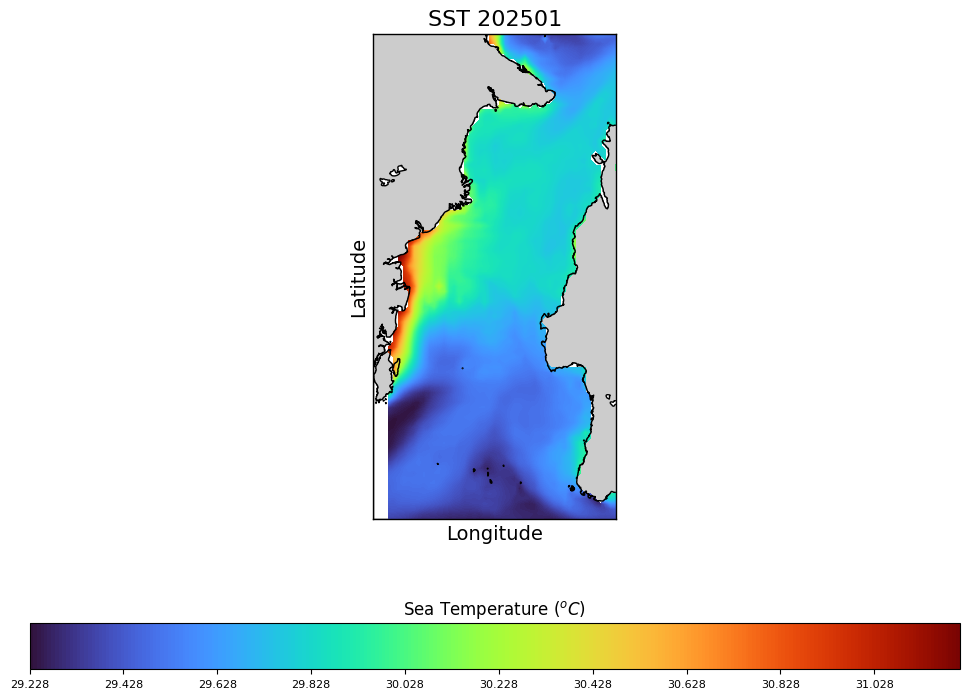

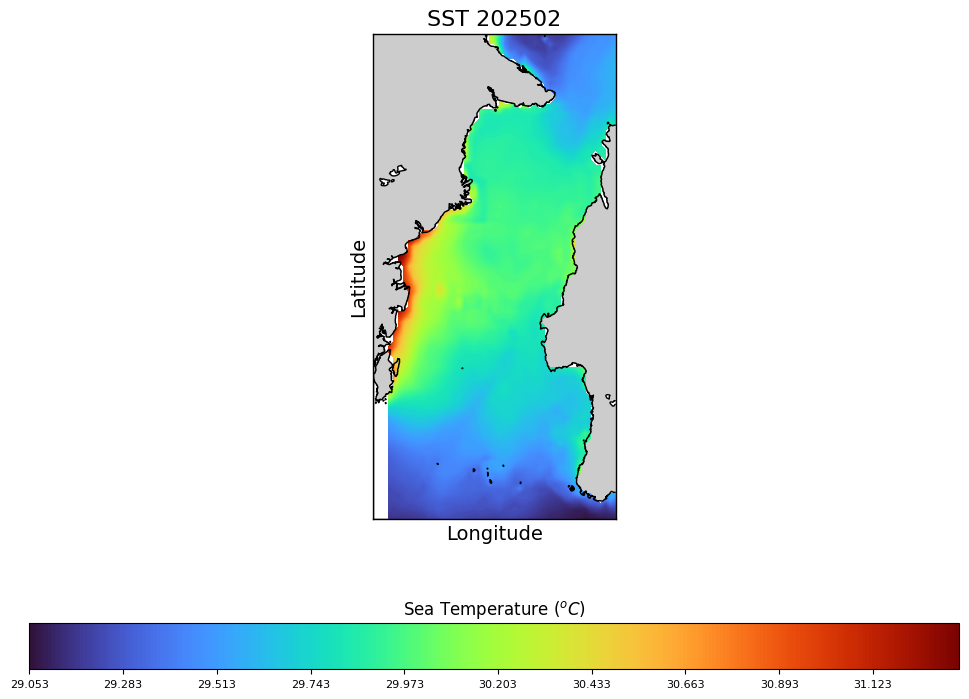

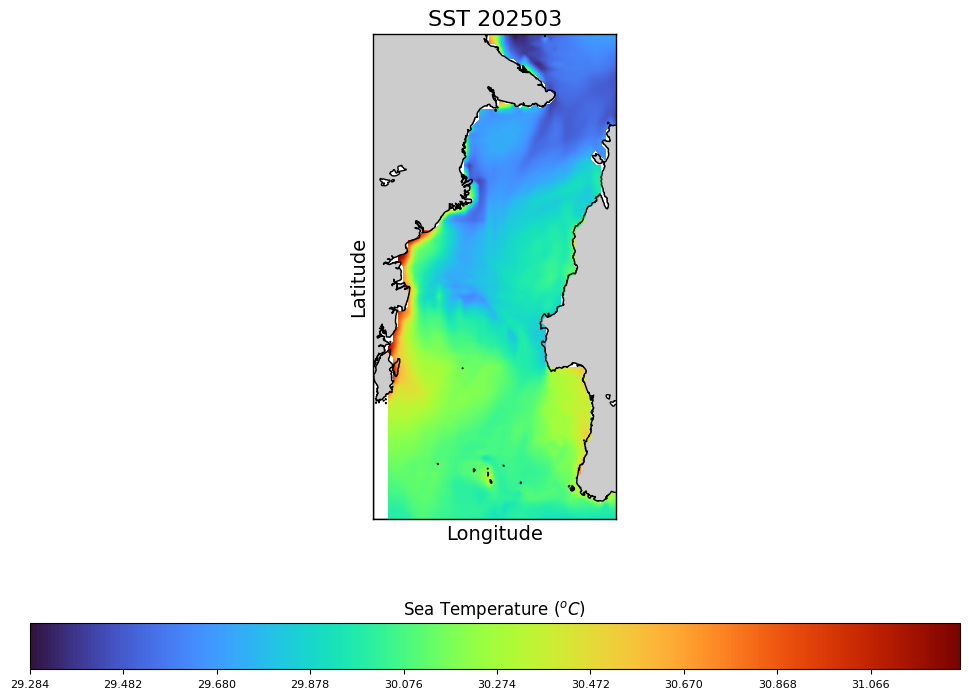

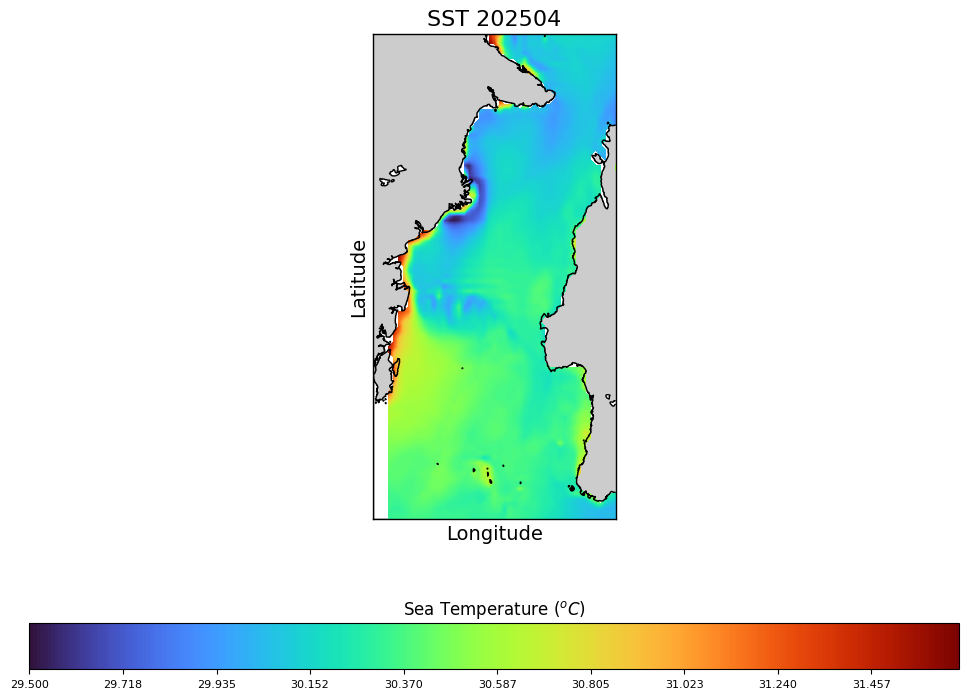

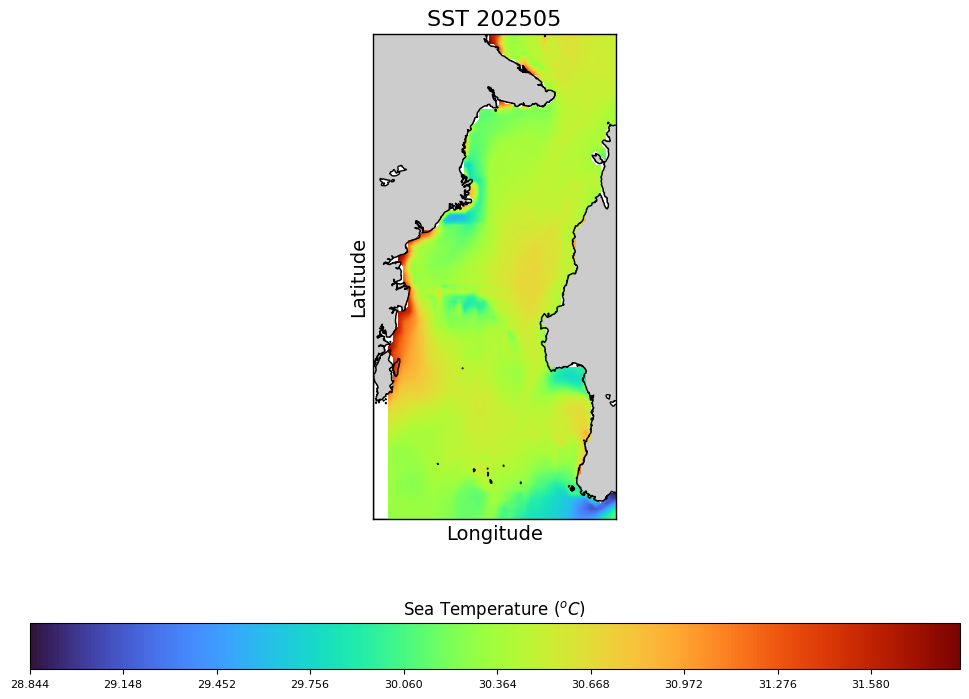

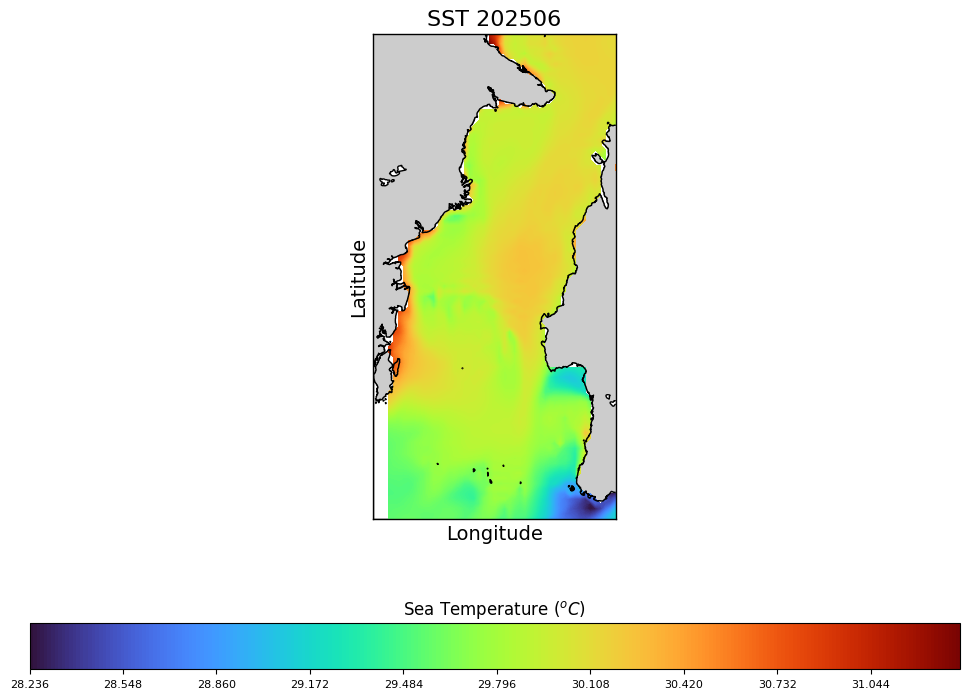

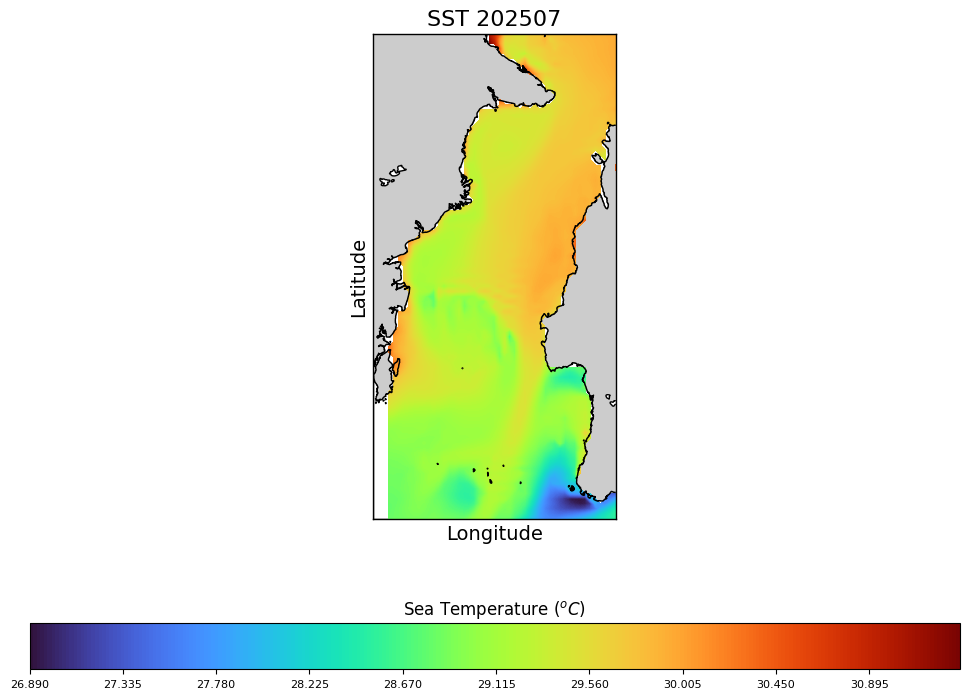

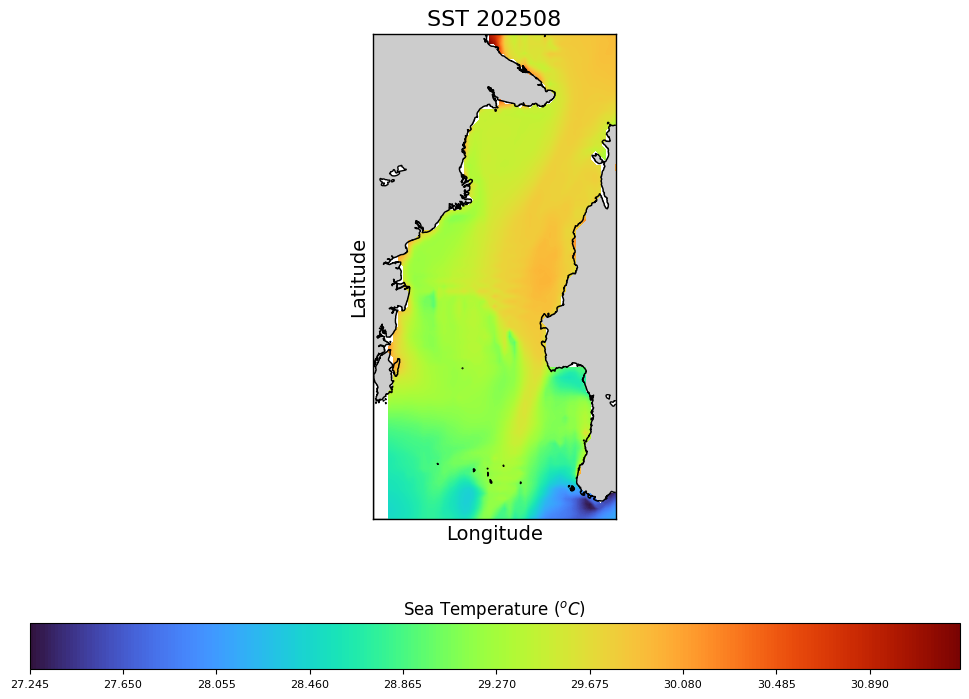

<Figure size 1200x900 with 0 Axes>

In [18]:
for i in range(2025,2027,1):
    year = str(i)
    location = 'C:/Users/user/Desktop/Python/Monthly SST/'+year+'/'
    list = os.listdir(location)
    number_files = len(list)
    for k in range(1, number_files+1,1):
        if k < 10:
            month = '0'+str(k)
        else:
            month = str(k)
        data = np.load(location+'vst_'+year+month+'.npz')
        sst = data['a']
        lat = data['b']
        lon = data['c']
        vis_sst = np.where((sst > -10), sst, 'NaN')
        x,y = np.meshgrid(lat,lon)
        plt.figure(figsize=(12,9),facecolor="white")
        map=Basemap(projection='mill',lat_ts=10,llcrnrlon=116,\
                    urcrnrlon=120,llcrnrlat=-6,urcrnrlat=2,resolution='f')
        lat_sng, lon_sng = map(x,y)
        map.drawmapboundary()
        map.fillcontinents()
        map.drawcoastlines() 
        lat_sng = np.asarray(lat_sng, dtype=float)
        lon_sng = np.asarray(lon_sng, dtype=float)
        vis_sst = np.asarray(vis_sst, dtype=float)    
        CF = map.contourf(lat_sng, lon_sng,vis_sst,1000,cmap='turbo')
        plt.title(f'SST {year+month}',fontsize=16)
        clb=plt.colorbar(CF, orientation='horizontal')
        clb.ax.tick_params(labelsize=8) 
        clb.ax.set_title('Sea Temperature $(^o C)$',fontsize=12)
        plt.xlabel('Longitude',fontsize=14)
        plt.ylabel('Latitude',fontsize=14)
        location2 = 'C:/Users/user/Desktop/Python/Hasil Monthly/'+year+'/'
        try:
            os.makedirs(location2)
        except:
            print(f'{year+month} Finish')
        plt.savefig(location2+f'sst_{year+month}.png')

Locator attempting to generate 1001 ticks ([28.885, ..., 31.385]), which exceeds Locator.MAXTICKS (1000).


2026 Finish


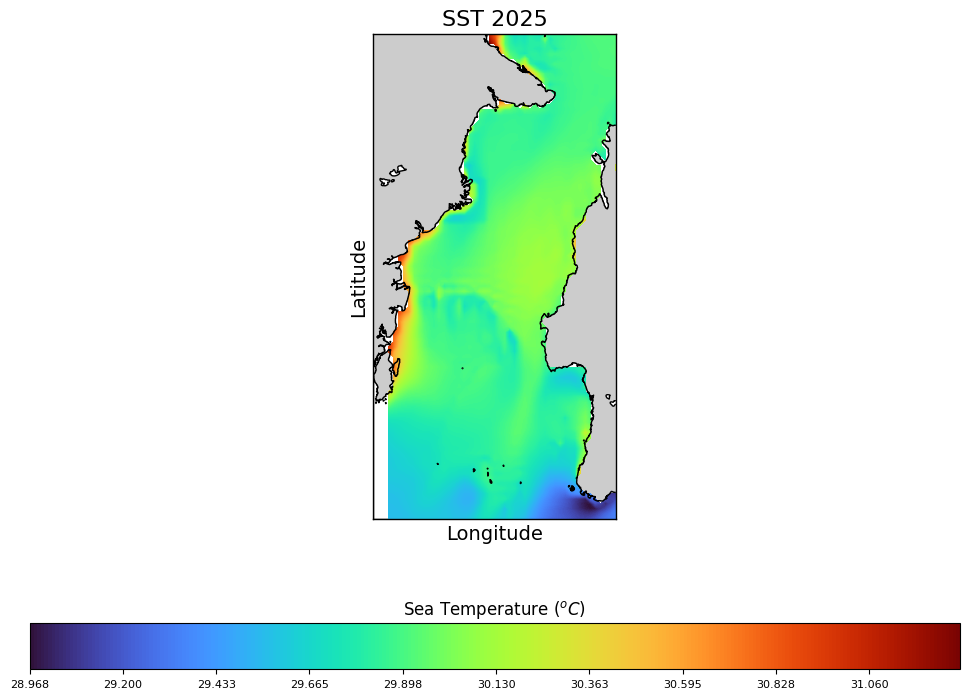

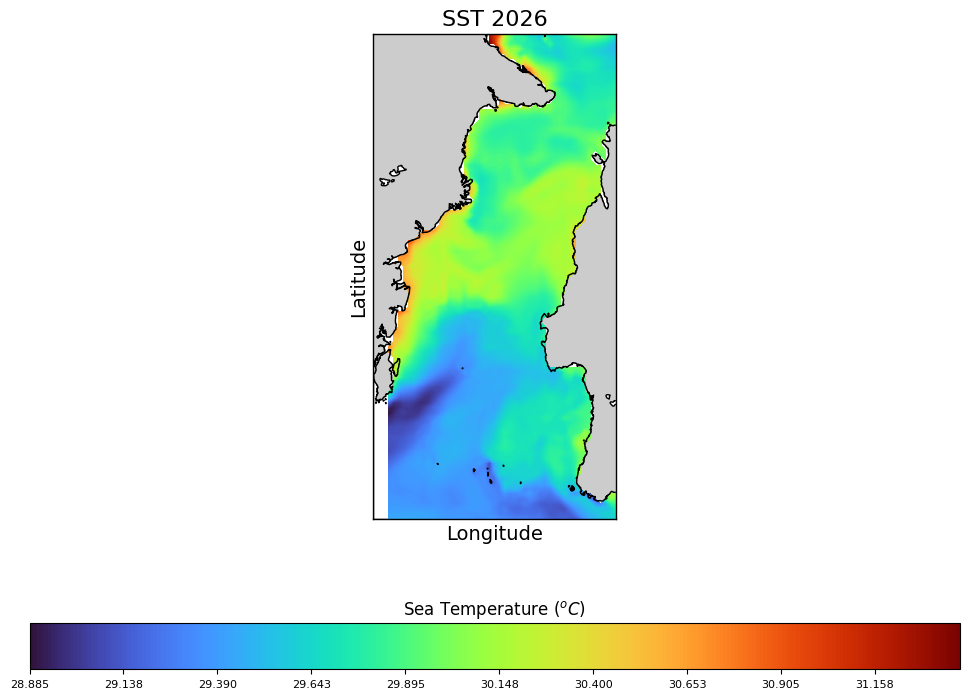

In [17]:
for i in range(2025,2027,1):
    year = str(i)
    location = 'C:/Users/user/Desktop/Python/Annual SST/'+year+'/'
    list = os.listdir(location)
    number_files = len(list)
    for j in range(1, number_files+1,1):
        year = str(i)
        if j < 10:
            month = '0'+str(j)
        else:
            month = str(j)
        data = np.load(location+'vst_'+year+'.npz')
        sst = data['a']
        lat = data['b']
        lon = data['c']
        vis_sst = np.where((sst > -10), sst, 'NaN')
        x,y = np.meshgrid(lat,lon)
        plt.figure(figsize=(12,9),facecolor="white")
        map=Basemap(projection='mill',lat_ts=10,llcrnrlon=116,\
                    urcrnrlon=120,llcrnrlat=-6,urcrnrlat=2,resolution='f')
        lat_sng, lon_sng = map(x,y)
        map.drawmapboundary()
        map.fillcontinents()
        map.drawcoastlines()
        lat_sng = np.asarray(lat_sng, dtype=float)
        lon_sng = np.asarray(lon_sng, dtype=float)
        vis_sst = np.asarray(vis_sst, dtype=float)    
        CF = map.contourf(lat_sng, lon_sng,vis_sst,1000,cmap='turbo')
        plt.title(f'SST {year}',fontsize=16)
        clb=plt.colorbar(CF, orientation='horizontal')
        clb.ax.tick_params(labelsize=8) 
        clb.ax.set_title('Sea Temperature $(^o C)$',fontsize=12)
        plt.xlabel('Longitude',fontsize=14)
        plt.ylabel('Latitude',fontsize=14)
        location2 = 'C:/Users/user/Desktop/Python/Hasil Annual/'
        try:
            os.makedirs(location2)
        except:
            print(f'{year} Finish')
        plt.savefig(location2+f'sst_{year}.png')